# Customer Churn Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
### Cleanup Total Charges

In [7]:
blank = (df['TotalCharges'].str.strip() == "")
print(f"Total blanks : {blank.sum()}")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(f"After filling missing values: {df['TotalCharges'].isnull().sum()}")

Total blanks : 11
After filling missing values: 0


In [8]:
print(f"Duplicates: {df['TotalCharges'].duplicated().sum()}")

Duplicates: 512


In [9]:
#Outliers
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['TotalCharges']<lower)| (df['TotalCharges']>upper)]
print('Outliers: ',len(outliers))

Outliers:  0


In [10]:
# Engineering tenure group

In [11]:
df['TenureGroup'] = pd.cut(df['tenure'],bins = [-1,12,48,72],
                           labels = ['New','Established','Loyal'])

In [12]:
df['TenureGroup'].value_counts().sort_index()

TenureGroup
New            2186
Established    2618
Loyal          2239
Name: count, dtype: int64

In [13]:
# Enginnering total services group

In [14]:
service_cols = [ 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',  'DeviceProtection',  'TechSupport', 'StreamingTV','StreamingMovies']
df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis = 1)

In [15]:
df['TotalServices'].value_counts().sort_index()

TotalServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

In [16]:
#Creating churn rates

In [17]:
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

In [18]:
df['ChurnFlag'].value_counts().sort_index()

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64

In [19]:
# Comparing churn rate by tenure group
result1 = df.groupby('TenureGroup',observed = True)['ChurnFlag'].mean()*100
result1.reset_index(name = 'ChurnRate')

,TenureGroup,ChurnRate
0,New,47.438243
1,Established,23.644003
2,Loyal,9.513176


In [20]:
# Comparing churn rate by total serivices
result2 = df.groupby('TotalServices',observed = True)['ChurnFlag'].mean()*100
result2.reset_index(name = 'ChurnRate')

,TotalServices,ChurnRate
0,0,43.750000
1,1,21.105232
2,2,32.828283
3,3,36.476684
4,4,31.344902
5,5,25.550661
6,6,22.485207
7,7,12.405063
8,8,5.288462


In [21]:
mystery = (df.groupby(["Contract", "TenureGroup", "TotalServices"],observed=True)
  .agg(
        ChurnRate=("ChurnFlag", "mean"),
        Customers=("ChurnFlag", "size")
    )
)
mystery["ChurnRate"] = (mystery["ChurnRate"] * 100).round(1)
top_mystery = mystery.sort_values("ChurnRate", ascending=False).head(10).reset_index()
top_mystery

,Contract,TenureGroup,TotalServices,ChurnRate,Customers
0,Month-to-month,New,7,75.0,4
1,Month-to-month,Established,8,75.0,4
2,Month-to-month,New,5,68.9,103
3,Month-to-month,New,6,62.5,24
4,Month-to-month,New,4,57.1,203
5,Month-to-month,New,2,56.6,512
6,Month-to-month,New,3,56.5,338
7,Month-to-month,New,0,55.4,56
8,Month-to-month,Established,6,45.8,120
9,Month-to-month,New,1,40.7,754


In [22]:
# Chart - 1

In [23]:
comparison = (df.groupby(["TenureGroup", "TotalServices"], observed=True)["ChurnFlag"] .mean().mul(100)  .reset_index())

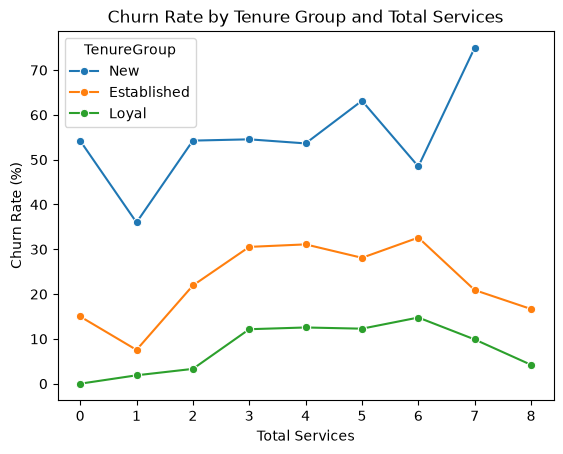

In [24]:
sns.lineplot(data=comparison,  x="TotalServices",   y="ChurnFlag",  hue="TenureGroup", marker="o")
plt.title("Churn Rate by Tenure Group and Total Services")
plt.xlabel("Total Services")
plt.ylabel("Churn Rate (%)")
plt.savefig("churn_tenure_services.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

In [25]:
# Chart 2

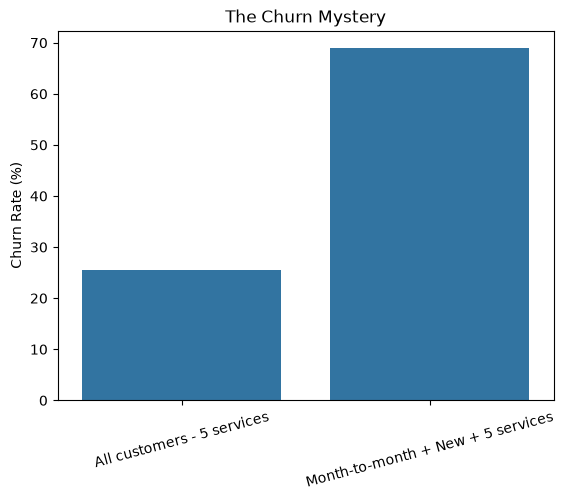

In [26]:
mystery_plot = pd.DataFrame({"Group": ["All customers - 5 services","Month-to-month + New + 5 services"], "ChurnRate": [25.6, 68.9]})
sns.barplot(data=mystery_plot, x="Group", y="ChurnRate")
plt.title("The Churn Mystery")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.savefig("churn_mystery.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

# Business Recommendations
1. Target new month-to-month customers with early retention offers and support.
2. Encourage longer term contracts through suitable discounts or incentives.
3. Use contract, tenure, and service count together to identify high-risk customers.

# Mystery
Month-to-month + New + 5 services has a 68.9% churn rate, compared with only 25.6% for all customers with 5 services. This shows that contract type and tenure can strongly influence churn, even when customers use multiple services.